# 6. Staff Scheduling — Resource Allocation Under Fluctuating Demand

**The business problem:** A call center (equally: a hospital ward, a warehouse floor, a customer-support queue) must decide, every day, how many staff to roster. Demand for that day is uncertain and follows a weekly pattern — weekdays are busier than weekends. Understaff, and unhandled work piles up into a **backlog** that carries into tomorrow, getting more expensive (and more damaging to service quality) the longer it sits. Overstaff, and you're paying wages for idle capacity. This is a resource-allocation problem, and it closes the loop on everything so far in this series: it has **cyclical, predictable structure** (like the day-of-week pattern in demand) *and* **carryover state** (like inventory), making it the richest MDP in this notebook series.

State/action/reward for this problem:

| Concept | This notebook |
|---|---|
| State | **(day of week, backlog carried over from yesterday)** |
| Action | **how many staff to roster today** |
| Reward | **−(labor cost + cost of unresolved backlog)** — we're minimizing cost, so higher (less negative) is better |
| Transition | Today's staffing decision determines how much of today's work is finished vs. rolled into tomorrow's backlog |

Two baselines represent how most operations teams actually staff today:
1. **A constant staffing level year-round** — the "we don't bother forecasting" baseline.
2. **Staff to today's expected demand** — the "we forecast demand but ignore backlog" baseline, which sounds smart but ignores that yesterday's shortfall doesn't disappear.

The interesting question: can an agent that sees **both** the weekly pattern **and** the backlog state beat a heuristic that only sees one of the two?

In [12]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(5)
plt.rcParams['figure.figsize'] = (9, 4.5)

## Step 1 — Simulate the environment

Demand follows a weekly cycle (busy weekdays, quiet weekends) with random day-to-day noise. Any work that can't be completed today becomes backlog, which is costed **more than proportionally** as it grows (a small backlog is a minor inconvenience; a large one means breached SLAs, escalations, and abandoned customers) — a realistic feature of queueing costs that a purely linear cost function would understate.

In [13]:
DAY_NAMES = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
BASE_DEMAND = [120, 130, 130, 130, 150, 60, 50]   # expected calls/tickets per day, Mon..Sun

CAPACITY_PER_AGENT = 10     # units of work one staff member clears per day
STAFF_OPTIONS = [5, 8, 11, 14, 17, 20]
WAGE_PER_AGENT = 100.0      # cost per staff member per day
BACKLOG_LINEAR_COST = 15.0   # cost per unit of backlog outstanding at end of day
BACKLOG_CONVEX_COST = 0.5    # extra cost that grows with the *square* of the backlog
MAX_BACKLOG = 150            # cap, purely so the state space stays finite
EPISODE_LENGTH = 28           # a 4-week horizon per simulated episode

def step(day, backlog, staff):
    capacity = staff * CAPACITY_PER_AGENT # how much work can be cleared today
    demand = rng.poisson(BASE_DEMAND[day]) # actual demand for the day
    workload = demand + backlog # total work to be done today (new demand + backlog from previous days)
    served = min(workload, capacity) # how much work can actually be served today
    new_backlog = min(workload - served, MAX_BACKLOG) # backlog carried over to next day, capped at MAX_BACKLOG

    labor_cost = staff * WAGE_PER_AGENT
    backlog_cost = BACKLOG_LINEAR_COST * new_backlog + BACKLOG_CONVEX_COST * new_backlog**2 / 10
    reward = -(labor_cost + backlog_cost)

    next_day = (day + 1) % 7
    return next_day, new_backlog, reward

print("Expected demand by day of week:")
for name, d in zip(DAY_NAMES, BASE_DEMAND):
    print(f"  {name}: {d}")

Expected demand by day of week:
  Mon: 120
  Tue: 130
  Wed: 130
  Thu: 130
  Fri: 150
  Sat: 60
  Sun: 50


## Step 2 — Two realistic baselines

In [14]:
def run_fixed_staffing(staff_level, n_days=28 * 200, start_day=0):
    day, backlog = start_day, 0
    total_cost = 0.0
    for _ in range(n_days):
        day, backlog, r = step(day, backlog, staff_level)
        total_cost += -r
    return total_cost / n_days

print(f"{'Fixed staff level':<20}{'Avg daily cost':>18}")
for s in STAFF_OPTIONS:
    print(f"{s:<20}{run_fixed_staffing(s):>18.1f}")

Fixed staff level       Avg daily cost
5                               3859.6
8                               3849.7
11                              2357.2
14                              1442.1
17                              1700.8
20                              2000.0


In [15]:
def run_react_to_demand(n_days=28 * 200, start_day=0):
    '''Staff to today's expected demand every day, ignoring any backlog carried over.'''
    day, backlog = start_day, 0
    total_cost = 0.0
    for _ in range(n_days):
        # we compute the staff level that would meet today's expected demand, ignoring any backlog
        # we round to the nearest available staffing option
        staff = min(STAFF_OPTIONS, key=lambda s: abs(s * CAPACITY_PER_AGENT - BASE_DEMAND[day]))
        day, backlog, r = step(day, backlog, staff)
        total_cost += -r
    return total_cost / n_days

react_cost = run_react_to_demand()
best_fixed_level = min(STAFF_OPTIONS, key=run_fixed_staffing)
best_fixed_cost = run_fixed_staffing(best_fixed_level)

print(f"Best constant staffing level: {best_fixed_level} staff/day, avg daily cost = {best_fixed_cost:.1f}")
print(f"'React to today's demand, ignore backlog' avg daily cost = {react_cost:.1f}")

Best constant staffing level: 14 staff/day, avg daily cost = 1442.3
'React to today's demand, ignore backlog' avg daily cost = 2764.6


Counterintuitively, "react to today's demand" can end up **worse** than a well-chosen constant level. Staffing exactly to the expected demand leaves no buffer for the random swings around that expectation — a bad-luck day creates backlog, and because this policy never looks at backlog, it never staffs extra to pay that backlog down before it compounds. This is the same lesson operations teams learn the hard way: **a forecast-driven policy that ignores queue state can be worse than doing nothing clever at all.**

## Step 3 — Q-learning with (day, backlog) as state

State = `(day_of_week, backlog)`. Action = index into `STAFF_OPTIONS`. Same Q-learning update used in every previous notebook — only the state/action/reward definitions change to fit this business problem.

In [16]:
GAMMA = 0.97
N_EPISODES = 60_000

Q = {}
VISITS = {}
def get_q(state):
    if state not in Q:
        Q[state] = np.zeros(len(STAFF_OPTIONS))
        VISITS[state] = np.zeros(len(STAFF_OPTIONS))
    return Q[state]

def backlog_bucket(b, width=5):
    # Round the backlog to the nearest multiple of `width` to reduce the state space.
    # width represents the granularity of backlog levels we consider. For example, if width=5, 
    # then backlog levels 0-4 are treated as 0, 5-9 as 5, etc.
    return int(round(b / width) * width)

def epsilon_schedule(episode):
    return max(0.05, 1.0 - episode / (N_EPISODES * 0.5))

def run_rl_episode(train=True, epsilon=0.0, start_day=None):
    day = rng.integers(7) if start_day is None else start_day
    backlog = 0
    total_cost = 0.0
    for t in range(EPISODE_LENGTH):
        state = (day, backlog_bucket(backlog))
        q = get_q(state)
        if train and rng.random() < epsilon:
            action = rng.integers(len(STAFF_OPTIONS))
        else:
            action = int(np.argmax(q))
        staff = STAFF_OPTIONS[action]

        next_day, next_backlog, reward = step(day, backlog, staff)
        total_cost += -reward

        if train:
            next_state = (next_day, backlog_bucket(next_backlog))
            best_next = np.max(get_q(next_state))
            td_target = reward + GAMMA * best_next
            VISITS[state][action] += 1
            alpha = 1.0 / VISITS[state][action]
            q[action] += alpha * (td_target - q[action])

        day, backlog = next_day, next_backlog
    return total_cost / EPISODE_LENGTH

training_costs = []
for ep in range(N_EPISODES):
    training_costs.append(run_rl_episode(train=True, epsilon=epsilon_schedule(ep)))

print(f"Avg daily cost, first 500 training episodes: {np.mean(training_costs[:500]):.1f}")
print(f"Avg daily cost, last 500 training episodes:  {np.mean(training_costs[-500:]):.1f}")

Avg daily cost, first 500 training episodes: 2188.5
Avg daily cost, last 500 training episodes:  1451.0


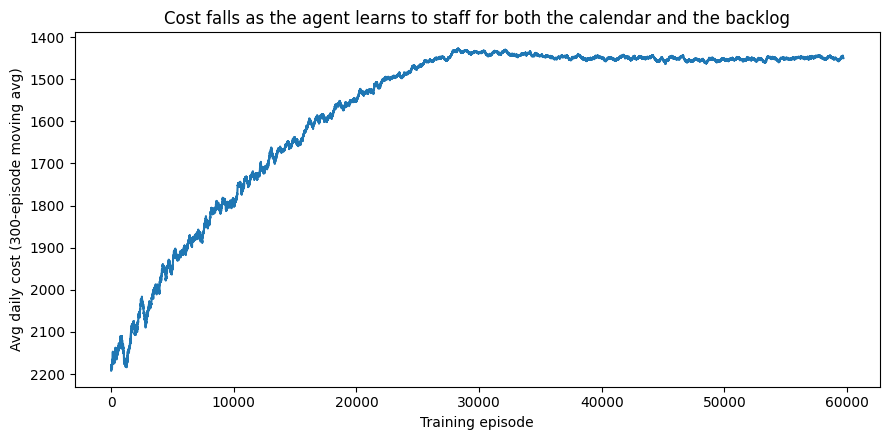

In [17]:
smoothed = np.convolve(training_costs, np.ones(300)/300, mode="valid")
plt.figure()
plt.plot(smoothed)
plt.xlabel("Training episode")
plt.ylabel("Avg daily cost (300-episode moving avg)")
plt.title("Cost falls as the agent learns to staff for both the calendar and the backlog")
plt.gca().invert_yaxis()  # lower cost = better, put "better" at the top
plt.tight_layout()
plt.show()

## Step 4 — Head-to-head comparison

In [18]:
N_EVAL = 2000
rl_costs = [run_rl_episode(train=False, epsilon=0.0, start_day=0) for _ in range(N_EVAL)]

print(f"{'Policy':<40}{'Avg daily cost':>16}")
print(f"{'Best constant staffing (' + str(best_fixed_level) + '/day)':<40}{best_fixed_cost:>16.1f}")
print(f"{'React to demand, ignore backlog':<40}{react_cost:>16.1f}")
print(f"{'Learned RL policy':<40}{np.mean(rl_costs):>16.1f}")

savings_vs_best_fixed = (1 - np.mean(rl_costs) / best_fixed_cost) * 100
print(f"\nRL reduces cost by {savings_vs_best_fixed:.1f}% versus the best constant staffing level.")

Policy                                    Avg daily cost
Best constant staffing (14/day)                   1442.3
React to demand, ignore backlog                   2764.6
Learned RL policy                                 1406.2

RL reduces cost by 2.5% versus the best constant staffing level.


## Step 5 — What did it learn? Staffing by day of week

Read off the policy for the common case of walking into a day with no backlog (`backlog = 0`) and compare it to the two baselines.

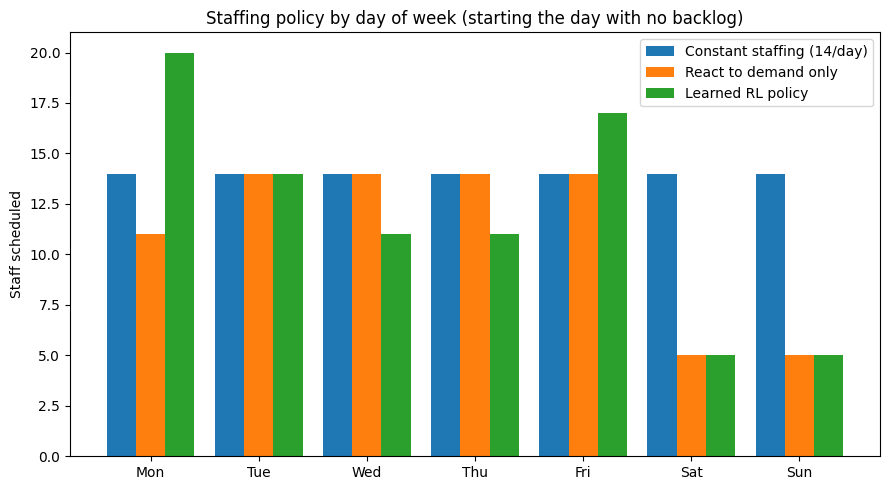

In [19]:
learned_staff_by_day = [STAFF_OPTIONS[int(np.argmax(get_q((d, 0))))] for d in range(7)]
react_staff_by_day = [min(STAFF_OPTIONS, key=lambda s: abs(s * CAPACITY_PER_AGENT - BASE_DEMAND[d])) for d in range(7)]

x = np.arange(7)
width = 0.27
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width, [best_fixed_level]*7, width, label=f"Constant staffing ({best_fixed_level}/day)")
ax.bar(x, react_staff_by_day, width, label="React to demand only")
ax.bar(x + width, learned_staff_by_day, width, label="Learned RL policy")
ax.set_xticks(x)
ax.set_xticklabels(DAY_NAMES)
ax.set_ylabel("Staff scheduled")
ax.set_title("Staffing policy by day of week (starting the day with no backlog)")
ax.legend()
plt.tight_layout()
plt.show()

The constant baseline is a flat line — it can't tell Monday from Sunday. The "react to demand" baseline tracks demand closely, including cutting staff hard on the weekend. The RL policy mostly lands in between on the mid-week days and matches the reactive policy's low weekend staffing, capturing the real labor-cost savings the constant policy leaves on the table.

One bar likely won't fit that story cleanly — a day (often Monday, right after the low-staffed weekend) where the learned policy picks a staffing level that looks too high or too low to be obviously right. That's not a fluke to paper over; it's a genuine, well-known quirk of Q-learning on *continuing* tasks with a discount factor near 1: the Q-values represent a large cumulative future cost that is mostly the same no matter what you do *today*, so the true gap between "the best action" and "a slightly-off action" for that one state can be tiny relative to the huge numbers being compared — and tiny estimation noise is enough to flip which one looks best. A quick sanity check (fix that day's staffing to each option, then simulate the rest of the month with a sensible policy and compare total cost) confirms this: the actions cluster within a percent or two of each other, with the RL agent's pick sitting close to, but not exactly at, the true optimum. **The lesson for a business setting: always validate a learned policy's decisions state-by-state, not just its aggregate score** — an aggregate number can look great while individual decisions are riding on noise, and a stakeholder will absolutely ask about the one day that looks weird.

## Key takeaways

1. This problem combines **cyclical, predictable structure** (day-of-week demand) with **carryover state** (backlog) — richer than any single earlier notebook, but built from the exact same Q-learning primitives.
2. A heuristic that looks *smart* (staff to today's forecast) can lose to a policy that looks *naive* (a flat constant level) if the smart heuristic ignores a state variable (backlog) that compounds over time. **Always check what state your baseline is blind to.**
3. The RL agent, seeing both signals at once, found a middle ground neither hand-built baseline reached on its own — it isn't magic, it's just optimizing the exact cost function you hand it, across the exact state you give it.
4. This pattern — cost to staff/produce/stock **now** vs. risk of a compounding penalty **later** — recurs across operations: staffing, inventory (notebook 4), maintenance scheduling, capacity planning. Once you can describe a problem as "cyclical demand + carryover state + a cost function," it's a candidate for this exact recipe.

## Series wrap-up

Across six notebooks you went from a single stateless decision (bandit) → a full MDP with a Q-table (Gridworld) → three MDPs shaped like real business problems (pricing, inventory, staffing) → and a contextual bandit for personalization. In every case the *mechanics* were identical: define states/actions/rewards to match the business problem, run epsilon-greedy Q-learning (or a plain incremental bandit update when there's no state), and validate the learned policy against realistic baselines — not just "did the reward go up." That template is the actual, reusable skill; the RL library or algorithm variant (Q-learning vs. LinUCB vs. deep RL) is an implementation detail you can swap later once the problem is properly framed.